## Langchain

In [1]:
# pip 설치 진행 시, pyproject.toml, uv.lock 에 기록이 된다
# requirements.txt 로 패키지 리스트를 뽑아야 한다.
# %pip install -q python-dotenv langchain-openai
# %pip install -q langchain-ollama

In [2]:
from dotenv import load_dotenv

load_dotenv()  # dotenv_path 파라미터를 가지고 .env의 경로를 넘겨주면 된다

True

In [3]:
# from langchain_openai import ChatOpenAI

# query = '인프런에는 어떤 강의가 있나요?'

# # .env의 변수명을 OPENAI_API_KEY 로 명명하면 자동으로 api 키값이 들어감
# # 그렇지 않다면 직접 api 를 ChatOpenAI 객체에 직접 지정해서 넣어줘야 함
# llm = ChatOpenAI(model='gpt-4o-mini') # 테스트의 경우에는 작은 모델로 활용
# llm.invoke(query)

- Billing 문제로 ChatOllama 로컬 LLM 활용

In [4]:
from langchain_ollama import ChatOllama

# cmd 창에서 `ollama pull <모델명>` 실행 
# 로컬LLM을 실행할 경우 .env에 있는 OPENAI_API_KEY와 load_dotenv()는 필요 없음
query = '인프런에는 어떤 강의가 있나요? 답변은 한국어로 해주세요'

llm = ChatOllama(
    model='qwen3:4b',
    temperature=0,
    )
llm.invoke(query)

AIMessage(content='인프런(Inflearn)은 다양한 분야의 강의를 제공합니다. 주요 강의 분야는 다음과 같습니다.\n\n1. **프로그래밍**: Python, Java, 웹 개발, 데이터 분석 등  \n2. **비즈니스**: 마케팅, 창업, 재무 관리, 경영학 등  \n3. **디자인**: UI/UX 디자인, 그래픽 디자인, 프로토타입 제작 등  \n4. **IT**: 클라우드 컴퓨팅, 암호학, 네트워크 관리 등  \n5. **생활 영역**: 프로젝트 관리, 개인 개발, 시간 관리 등  \n6. **과학 및 공학**: 물리, 화학, 전자공학 등  \n7. **언어**: 영어, 일본어, 중국어 등  \n8. **기타**: 사회학, 경제학, 심리학 등  \n\n이 외에도 인프런은 특정 주제에 대한 심층 강의와 실전 프로젝트를 포함한 실용적인 강의를 제공합니다.', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-09-27T05:00:16.8152088Z', 'done': True, 'done_reason': 'stop', 'total_duration': 176713265600, 'load_duration': 7402100, 'prompt_eval_count': 29, 'prompt_eval_duration': 168592000, 'eval_count': 1364, 'eval_duration': 176416691000, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--01a0e139-8be3-7f12-bcbf-009c26f357c1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 29, 'output_tokens': 1364, 'total_tokens': 1393})

## Langgraph

In [5]:
# %pip install -q langgraph

In [6]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list [Annotated[AnyMessage, add_messages]]

In [7]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)  # 빌더 생성

In [8]:
# 노드 생성

def generate(state: AgentState) -> AgentState:  # node 이기 때문에 state를 인자로 받는다

    messages = state['messages']
    ai_messages = llm.invoke(messages)  # llm 호출

    return {'messages': [ai_messages]}  # messages가 리스트 형태이므로, []로 감싼다

In [9]:
graph_builder.add_node('generate', generate) # 노드이름, 메서드

In [10]:
# 모든 랭그래프 에이전트는 start 와 end를 가진다
# start와 end는 엣지

from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [11]:
# 그래프 컴파일

graph = graph_builder.compile()

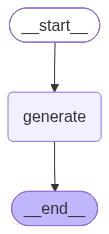

In [12]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

### LLM invoke
- LLM에서 호출해서 답변을 생성 (Basic)

In [ ]:
from langchain_core.messages import HumanMessage

# 기본 state 생성하기
## 사용자가 질문을 하는 거니까 HumanMessage 에 query 를 넣고 invoke 를 해주면? : langgraph를 통해서 답변을 받아낼 수 있다.
initial_state = {'messages' : [HumanMessage(query)]}  # 초기 state 생성
graph.invoke(initial_state)  

In [ ]:
# Insights
## LLM 호출은 매우 간단 => Langgraph로 구현할 필요는 없음 (오히려 오버 엔지니어링이 될 수 있음)
## 불필요하게 패키지를 설치해놓는 것일 수도 있다

## Langchain 으로 충분히 서비스를 만들 수 있는지 검증을 해보자
## 서비스를 고도화를 하거나, 꼭 랭그래프로 만들어야 한다고 하면 그때 사용하는 걸 추천